<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/8825_preset_350_microns_analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
df = pd.read_excel('/content/drive/MyDrive/preset 350 microns study.xlsx')

In [2]:
df.head()

,Name,Date,Age,Unnamed: 3,Males,Females,RE(Preop diagnosis),LE(Preop diagnosis),RE IOP,LE IOP,...,LE R1,LE R2,LE A1,RE-AL,RE-ACD,RE LT,LE-AL,LE-ACD,LE LT,IOLP
0,Deviramma,19/1/2025,55,NaN,0,1,PPC,PPC,14.0,12.0,...,NaN,NaN,NaN,23.04,3.49,4.02,NaN,NaN,NaN,21.5
1,Sakamma,19/1/2025,69,NaN,0,1,SMC,PCIOL,9.0,8.0,...,NaN,NaN,NaN,21.87,2.82,3.66,NaN,NaN,NaN,25
2,Malamma,19/1/2025,64,NaN,0,1,PCIOL,SMC,13.0,12.0,...,44.5,46.0,95.0,NaN,NaN,NaN,22.41,3.01,3.82,21.5
3,Rajkumar,21/1/2025,57,NaN,1,0,NC,NC,10.0,10.0,...,NaN,NaN,NaN,24.17,3.67,3.72,NaN,NaN,NaN,18.5
4,Chanappa,21/1/25,79,NaN,1,0,NC,PTHYSIS BULBI,9.0,14.0,...,NaN,NaN,NaN,22.84,3.32,3.83,NaN,NaN,NaN,22.5


In [3]:
sheets = pd.ExcelFile('/content/drive/MyDrive/preset 350 microns study.xlsx')
sheets.sheet_names

['preop rawdata',
 'postop day 1 rawdata',
 'pre n postop AK',
 '2 MONTHS AK',
 'workup at 2 mth']

In [4]:
ak = sheets.parse('pre n postop AK')
ak.head()

,Name,age,gender,Males,Females,preop kh,preop kv,preop axis,postop kh,postop kv,postop axis
0,Deviramma,55,f,0,1,43.50,43.75,35,43.25,43.25,180
1,Sakamma,69,f,0,1,43.00,44.00,75,43.25,43.75,135
2,Malamma,64,f,0,1,44.50,46.00,95,45.25,48.50,180
3,Rajkumar,57,m,1,0,43.25,44.50,60,43.00,44.75,60
4,Chanappa,79,m,1,0,42.25,43.75,100,43.00,43.25,120


In [5]:
ak.columns

Index(['Name', 'age', 'gender', 'Males', 'Females', 'preop kh', 'preop kv',
       'preop axis', 'postop kh', 'postop kv', 'postop axis'],
      dtype='object')

array([[<Axes: title={'center': 'preop kh'}>,
        <Axes: title={'center': 'postop kh'}>]], dtype=object)

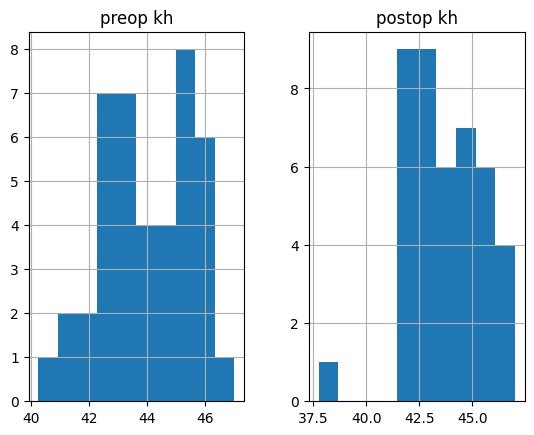

In [6]:
ak[['preop kh','postop kh']].hist()

<Axes: >

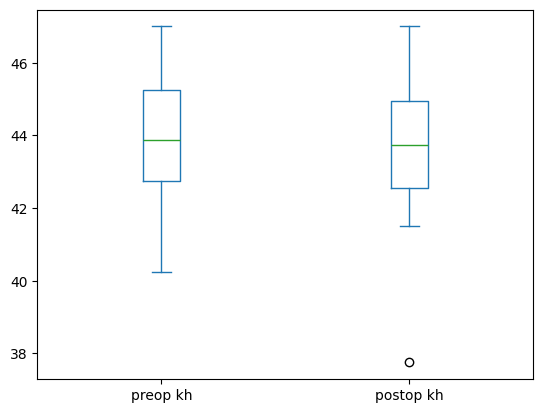

In [7]:
ak[['preop kh','postop kh']].plot.box()

array([[<Axes: title={'center': 'preop kv'}>,
        <Axes: title={'center': 'postop kv'}>]], dtype=object)

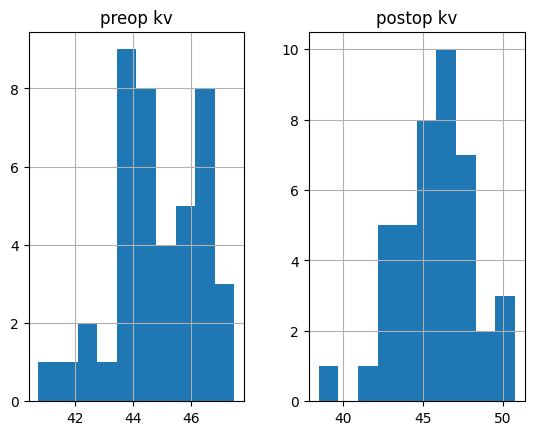

In [8]:
ak[['preop kv','postop kv']].hist()

<Axes: >

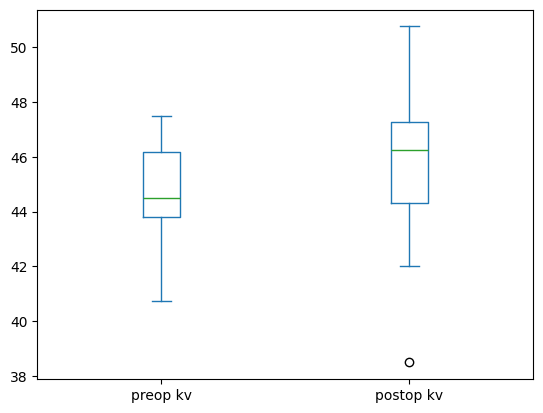

In [9]:
ak[['preop kv','postop kv']].plot.box()

array([[<Axes: title={'center': 'preop axis'}>,
        <Axes: title={'center': 'postop axis'}>]], dtype=object)

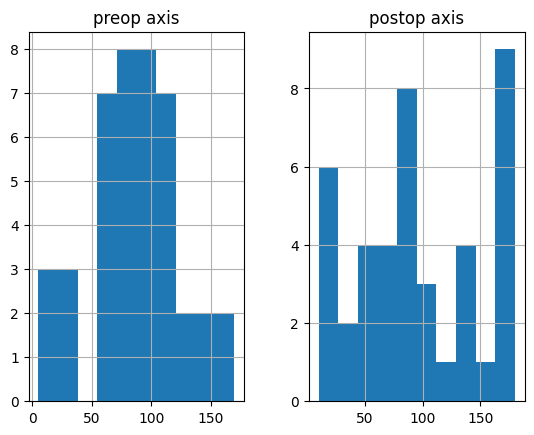

In [10]:
ak[['preop axis','postop axis']].hist()

<Axes: >

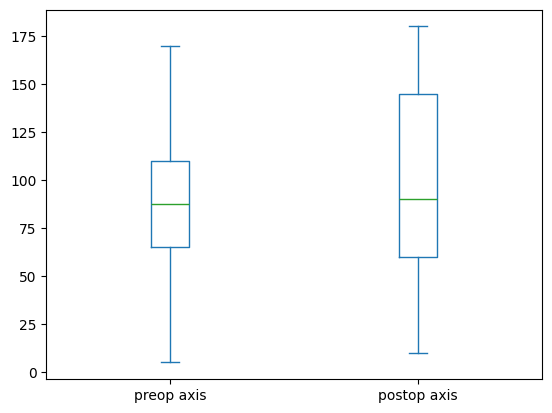

In [11]:
ak[['preop axis','postop axis']].plot.box()

<Axes: xlabel='preop kh', ylabel='postop kh'>

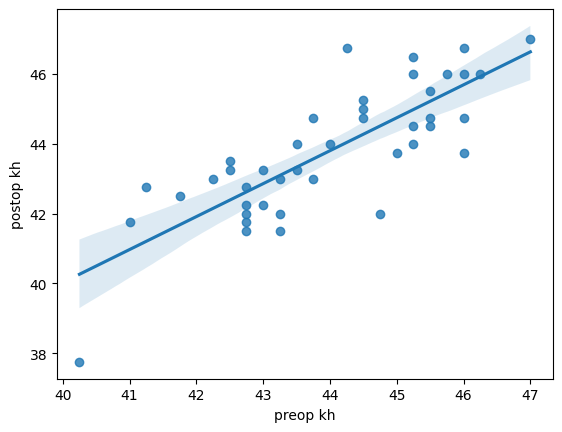

In [12]:
import seaborn as sns
sns.regplot(x='preop kh', y='postop kh', data=ak)

<Axes: xlabel='preop kv', ylabel='postop kv'>

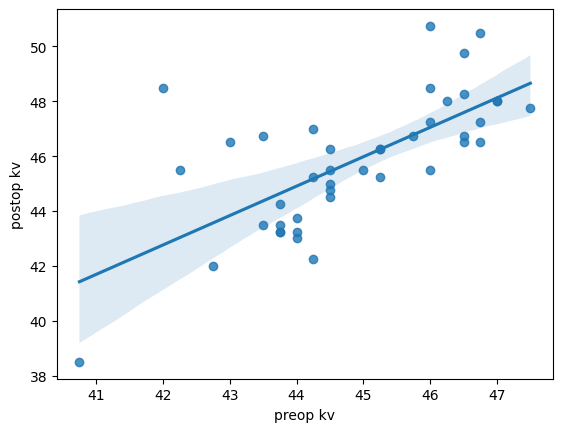

In [13]:
import seaborn as sns
sns.regplot(x='preop kv', y='postop kv', data=ak)

<Axes: xlabel='preop axis', ylabel='postop axis'>

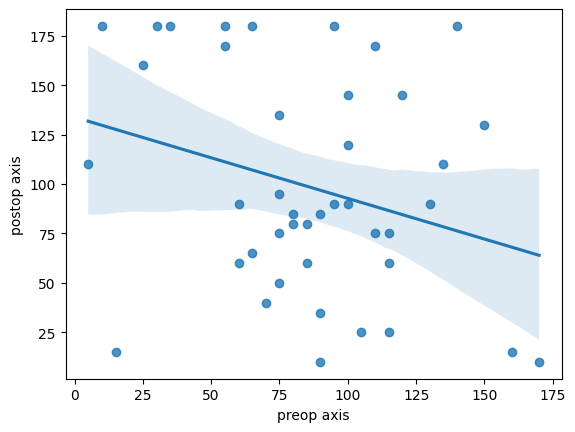

In [14]:
import seaborn as sns
sns.regplot(x='preop axis', y='postop axis', data=ak)

In [15]:
ak[['preop kh','postop kh','preop kv','postop kv','preop axis','postop axis']].corr()



,preop kh,postop kh,preop kv,postop kv,preop axis,postop axis
preop kh,1.000000,0.806587,0.938398,0.635851,-0.009172,0.076634
postop kh,0.806587,1.000000,0.871098,0.696536,-0.033536,0.013589
preop kv,0.938398,0.871098,1.000000,0.685391,-0.026529,0.032285
postop kv,0.635851,0.696536,0.685391,1.000000,0.027544,-0.121509
preop axis,-0.009172,-0.033536,-0.026529,0.027544,1.000000,-0.286856
postop axis,0.076634,0.013589,0.032285,-0.121509,-0.286856,1.000000


In [16]:
columns_to_drop = ['Name', 'Males', 'Females']
existing_columns = [col for col in columns_to_drop if col in ak.columns]
ak.drop(existing_columns, axis=1, inplace=True)

In [17]:
ak.columns

Index(['age', 'gender', 'preop kh', 'preop kv', 'preop axis', 'postop kh',
       'postop kv', 'postop axis'],
      dtype='object')

/tmp/ipython-input-1093815733.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ak['gender'] = ak['gender'].replace({'f': 0, 'm': 1})


<Axes: >

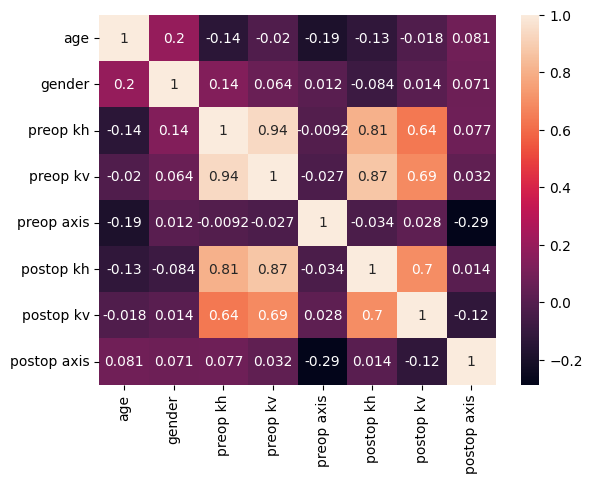

In [18]:
ak['gender'] = ak['gender'].replace({'f': 0, 'm': 1})
sns.heatmap(ak.corr(), annot=True)

In [19]:
ak['age'].describe()

,age
count,42.000000
mean,67.142857
std,9.235592
min,39.000000
25%,60.500000
50%,65.000000
75%,75.500000
max,82.000000


<Axes: >

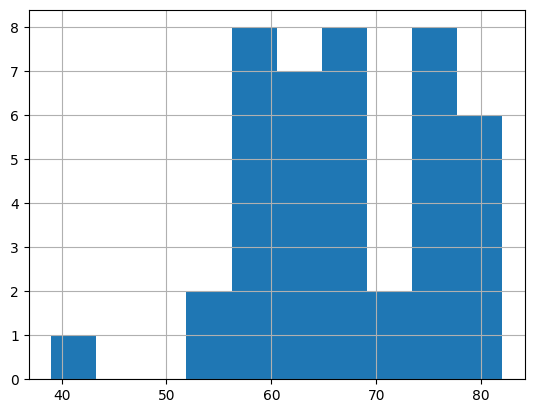

In [20]:
ak['age'].hist()

<Axes: >

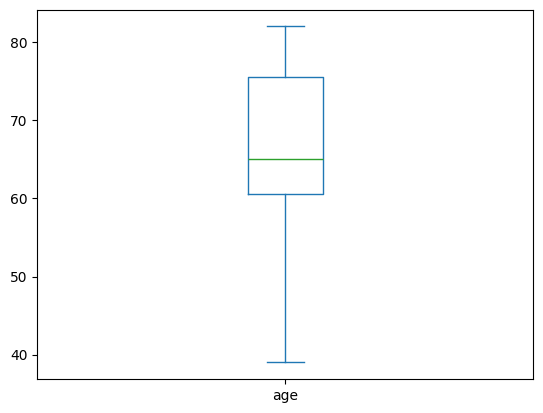

In [21]:
ak['age'].plot.box()

<Axes: xlabel='gender', ylabel='age'>

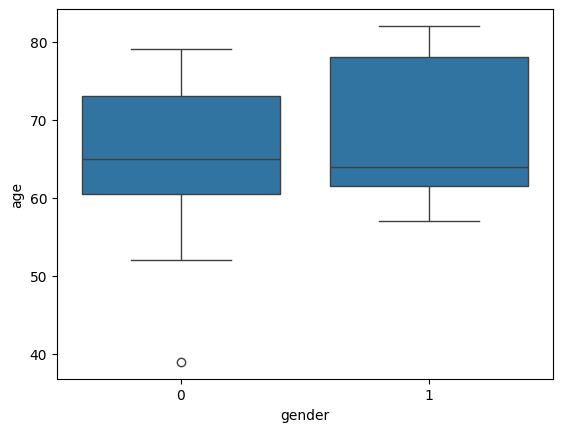

In [22]:
sns.boxplot(x='gender', y='age', data=ak)

In [23]:
from scipy.stats import chi2_contingency

# Create age groups
bins = [30, 40, 50, 60, 70, 80, 90]
labels = ['30-40', '41-50', '51-60', '61-70', '71-80', '81-90']
ak['age_group'] = pd.cut(ak['age'], bins=bins, labels=labels, right=False)

# Create a contingency table
contingency_table = pd.crosstab(ak['gender'], ak['age_group'])

# Perform the chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("p-value:", p)

Chi-square statistic: 6.495324283559578
p-value: 0.16508522975373424


In [24]:
from scipy.stats import ttest_ind

# Separate the data for males and females
male_data = ak[ak['gender'] == 1]
female_data = ak[ak['gender'] == 0]

# Perform t-test for each numerical column
for col in ['age']:
    ttest_result = ttest_ind(male_data[col], female_data[col])
    print(f"T-test for {col}:")
    print(f"  T-statistic: {ttest_result.statistic}")
    print(f"  P-value: {ttest_result.pvalue}\n")

T-test for age:
  T-statistic: 1.2591783543464743
  P-value: 0.21526462430462526



In [25]:
from scipy.stats import ttest_rel

# Perform paired t-test for each pair of pre- and post-operative columns
for col_pair in [('preop kh', 'postop kh'), ('preop kv', 'postop kv'), ('preop axis', 'postop axis')]:
    col1, col2 = col_pair
    ttest_result = ttest_rel(ak[col1], ak[col2])
    print(f"Paired T-test for {col1} vs {col2}:")
    print(f"  T-statistic: {ttest_result.statistic}")
    print(f"  P-value: {ttest_result.pvalue}\n")

Paired T-test for preop kh vs postop kh:
  T-statistic: 1.151981757917686
  P-value: 0.25600170978077436

Paired T-test for preop kv vs postop kv:
  T-statistic: -3.5566906425154396
  P-value: 0.0009643948362361833

Paired T-test for preop axis vs postop axis:
  T-statistic: -1.0507888094590356
  P-value: 0.29950987989464306



In [26]:
ak.columns

Index(['age', 'gender', 'preop kh', 'preop kv', 'preop axis', 'postop kh',
       'postop kv', 'postop axis', 'age_group'],
      dtype='object')

In [27]:
ak.head()

,age,gender,preop kh,preop kv,preop axis,postop kh,postop kv,postop axis,age_group
0,55,0,43.50,43.75,35,43.25,43.25,180,51-60
1,69,0,43.00,44.00,75,43.25,43.75,135,61-70
2,64,0,44.50,46.00,95,45.25,48.50,180,61-70
3,57,1,43.25,44.50,60,43.00,44.75,60,51-60
4,79,1,42.25,43.75,100,43.00,43.25,120,71-80


In [28]:
ak['preopcyl']=ak['preop kv']-ak['preop kh']
ak['postopcyl']=ak['postop kv']-ak['postop kh']
ak['preoptheta']=np.radians(ak['preop axis'])*2
ak['postoptheta']=np.radians(ak['postop axis'])*2
ak['xpre']=ak['preopcyl']*np.cos(ak['preoptheta'])
ak['ypre'] = ak['preopcyl']*np.sin(ak['preoptheta'])
ak['xpost'] = ak['postopcyl']*np.cos(ak['postoptheta'])
ak['ypost'] = ak['postopcyl']*np.sin(ak['postoptheta'])
ak['Xsia'] = ak['xpost'] - ak['xpre']
ak['Ysia'] = ak['ypost'] - ak['ypre']
ak['SIA_magnitude'] = np.sqrt(ak['Xsia']**2 + ak['Ysia']**2)
ak['SIA_axis'] = np.degrees(np.arctan2(ak['Ysia'], ak['Xsia'])/2)%180.0


SIA Magnitude: 0.25 D
SIA Axis: 125.0°


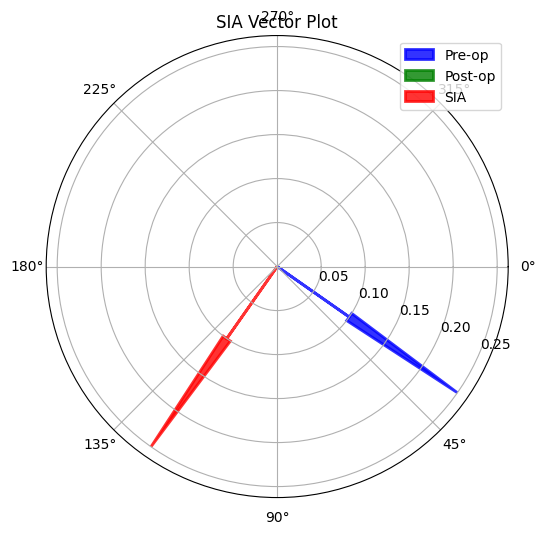

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# ==== Input: Pre-op and Post-op Astigmatism ====
pre_cyl = 0.25
pre_axis = 35

post_cyl = 0.0
post_axis = 180

# ==== Convert Cyl and Axis to X, Y (Cartesian) ====
def cyl_to_cartesian(cyl, axis_deg):
    axis_rad = np.deg2rad(axis_deg * 2)  # Double angle for astigmatism vectors
    x = cyl * np.cos(axis_rad)
    y = cyl * np.sin(axis_rad)
    return x, y

# Pre-op and Post-op Cartesian Vectors
pre_x, pre_y = cyl_to_cartesian(pre_cyl, pre_axis)
post_x, post_y = cyl_to_cartesian(post_cyl, post_axis)

# ==== SIA Vector (Post - Pre) ====
sia_x = post_x - pre_x
sia_y = post_y - pre_y

# ==== Convert SIA Vector to Cyl and Axis ====
def cartesian_to_cyl(x, y):
    cyl = np.sqrt(x**2 + y**2)
    axis_rad = 0.5 * np.arctan2(y, x)
    axis_deg = np.rad2deg(axis_rad) % 180
    return cyl, axis_deg

sia_cyl, sia_axis = cartesian_to_cyl(sia_x, sia_y)

print(f"SIA Magnitude: {sia_cyl:.2f} D")
print(f"SIA Axis: {sia_axis:.1f}°")

# ==== Plotting on Polar Graph ====
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, polar=True)
ax.set_theta_zero_location("E")
ax.set_theta_direction(-1)
ax.set_title("SIA Vector Plot")

# Helper to plot vectors
def plot_vector(ax, cyl, axis_deg, label, color):
    r = cyl
    theta = np.deg2rad(axis_deg)
    ax.arrow(theta, 0, 0, r, linewidth=2, color=color, label=label, alpha=0.8, length_includes_head=True, head_width=0.1)

# Plot each vector
plot_vector(ax, pre_cyl, pre_axis, "Pre-op", "blue")
plot_vector(ax, post_cyl, post_axis, "Post-op", "green")
plot_vector(ax, sia_cyl, sia_axis, "SIA", "red")

ax.legend(loc='upper right')
plt.show()


Pre-op vector:     X = 0.09, Y = 0.23
Post-op vector:    X = 0.00, Y = -0.00
SIA vector:        ΔX = -0.09, ΔY = -0.23
SIA Magnitude:     0.25 D
SIA Axis:          125.00°


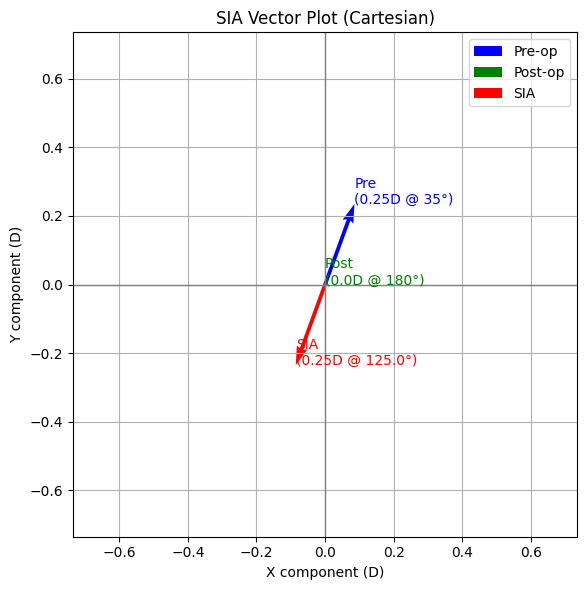

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# --- Input values ---
pre_cyl = 0.25  # diopters
pre_axis = 35   # degrees

post_cyl = 0.0  # diopters
post_axis = 180  # degrees

# --- Convert cylinder and axis to Cartesian coordinates ---
def to_cartesian(cyl, axis_deg):
    angle_rad = np.deg2rad(axis_deg * 2)  # x2 for vector doubling
    x = cyl * np.cos(angle_rad)
    y = cyl * np.sin(angle_rad)
    return x, y

# Pre-op vector
pre_x, pre_y = to_cartesian(pre_cyl, pre_axis)

# Post-op vector
post_x, post_y = to_cartesian(post_cyl, post_axis)

# --- SIA vector (Post - Pre) ---
sia_x = post_x - pre_x
sia_y = post_y - pre_y

# --- Calculate SIA magnitude and axis (Pythagorean method) ---
sia_magnitude = np.sqrt(sia_x**2 + sia_y**2)
sia_axis = (np.arctan2(sia_y, sia_x) / 2) * (180 / np.pi)  # divide by 2 for true axis
sia_axis = sia_axis % 180  # Keep axis in 0–180°

# --- Display values ---
print(f"Pre-op vector:     X = {pre_x:.2f}, Y = {pre_y:.2f}")
print(f"Post-op vector:    X = {post_x:.2f}, Y = {post_y:.2f}")
print(f"SIA vector:        ΔX = {sia_x:.2f}, ΔY = {sia_y:.2f}")
print(f"SIA Magnitude:     {sia_magnitude:.2f} D")
print(f"SIA Axis:          {sia_axis:.2f}°")

# --- Plotting ---
plt.figure(figsize=(6, 6))
plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)

# Plot vectors
plt.quiver(0, 0, pre_x, pre_y, angles='xy', scale_units='xy', scale=1, color='blue', label='Pre-op')
plt.quiver(0, 0, post_x, post_y, angles='xy', scale_units='xy', scale=1, color='green', label='Post-op')
plt.quiver(0, 0, sia_x, sia_y, angles='xy', scale_units='xy', scale=1, color='red', label='SIA')

# Add text labels
plt.text(pre_x, pre_y, f'Pre\n({pre_cyl}D @ {pre_axis}°)', color='blue')
plt.text(post_x, post_y, f'Post\n({post_cyl}D @ {post_axis}°)', color='green')
plt.text(sia_x, sia_y, f'SIA\n({sia_magnitude:.2f}D @ {sia_axis:.1f}°)', color='red')

# Axis limits and labels
max_val = max(abs(pre_x), abs(pre_y), abs(post_x), abs(post_y), abs(sia_x), abs(sia_y)) + 0.5
plt.xlim(-max_val, max_val)
plt.ylim(-max_val, max_val)
plt.xlabel('X component (D)')
plt.ylabel('Y component (D)')
plt.title('SIA Vector Plot (Cartesian)')
plt.grid(True)
plt.gca().set_aspect('equal')
plt.legend()
plt.tight_layout()
plt.show()


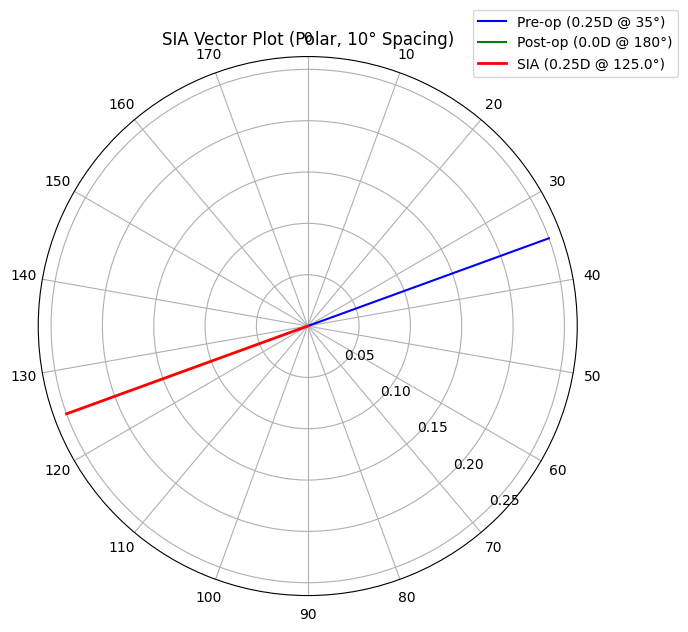

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# --- Input values ---
pre_cyl = 0.25  # diopters
pre_axis = 35   # degrees

post_cyl = 0.0  # diopters
post_axis = 180  # degrees

# --- Convert cylinder and axis to Cartesian coordinates with vector doubling ---
def to_cartesian(cyl, axis_deg):
    angle_rad = np.deg2rad(axis_deg * 2)  # vector doubling
    x = cyl * np.cos(angle_rad)
    y = cyl * np.sin(angle_rad)
    return x, y

# --- Calculate vectors ---
pre_x, pre_y = to_cartesian(pre_cyl, pre_axis)
post_x, post_y = to_cartesian(post_cyl, post_axis)

sia_x = post_x - pre_x
sia_y = post_y - pre_y

# --- SIA vector magnitude and axis ---
sia_magnitude = np.hypot(sia_x, sia_y)
sia_axis = (np.arctan2(sia_y, sia_x) / 2) * (180 / np.pi) % 180  # half angle for astigmatism axis

# --- Polar plot values (angles doubled) ---
pre_angle_rad = np.deg2rad(pre_axis * 2)
post_angle_rad = np.deg2rad(post_axis * 2)
sia_angle_rad = np.arctan2(sia_y, sia_x)

# --- Plotting ---
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, polar=True)

# Set 10° interval for radial grid (doubled = 0–360)
ax.set_thetagrids(range(0, 360, 20), labels=[str(i//2) for i in range(0, 360, 20)])
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)  # Clockwise

# Plot vectors
ax.plot([0, pre_angle_rad], [0, pre_cyl], label=f'Pre-op ({pre_cyl}D @ {pre_axis}°)', color='blue')
ax.plot([0, post_angle_rad], [0, post_cyl], label=f'Post-op ({post_cyl}D @ {post_axis}°)', color='green')
ax.plot([0, sia_angle_rad], [0, sia_magnitude], label=f'SIA ({sia_magnitude:.2f}D @ {sia_axis:.1f}°)', color='red', linewidth=2)

# Aesthetic
ax.set_title("SIA Vector Plot (Polar, 10° Spacing)", va='bottom')
ax.set_rlabel_position(135)
ax.grid(True)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))

plt.show()


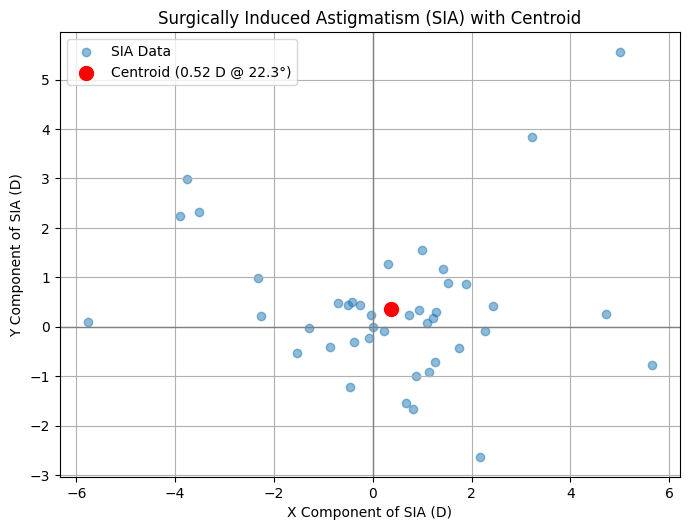

Centroid Magnitude: 0.52 D
Centroid Axis: 22.3°


In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate the centroid of the SIA data
centroid_x = np.mean(ak['Xsia'])
centroid_y = np.mean(ak['Ysia'])

# Convert the centroid to polar coordinates
centroid_magnitude = np.sqrt(centroid_x**2 + centroid_y**2)
centroid_axis = np.degrees(np.arctan2(centroid_y, centroid_x) / 2) % 180

# Create a scatter plot of the SIA data with the centroid
plt.figure(figsize=(8, 8))
plt.scatter(ak['Xsia'], ak['Ysia'], alpha=0.5, label='SIA Data')
plt.scatter(centroid_x, centroid_y, color='red', s=100, zorder=5, label=f'Centroid ({centroid_magnitude:.2f} D @ {centroid_axis:.1f}°)')
plt.axhline(0, color='grey', lw=1)
plt.axvline(0, color='grey', lw=1)
plt.xlabel('X Component of SIA (D)')
plt.ylabel('Y Component of SIA (D)')
plt.title('Surgically Induced Astigmatism (SIA) with Centroid')
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)
plt.legend()
plt.show()

print(f"Centroid Magnitude: {centroid_magnitude:.2f} D")
print(f"Centroid Axis: {centroid_axis:.1f}°")

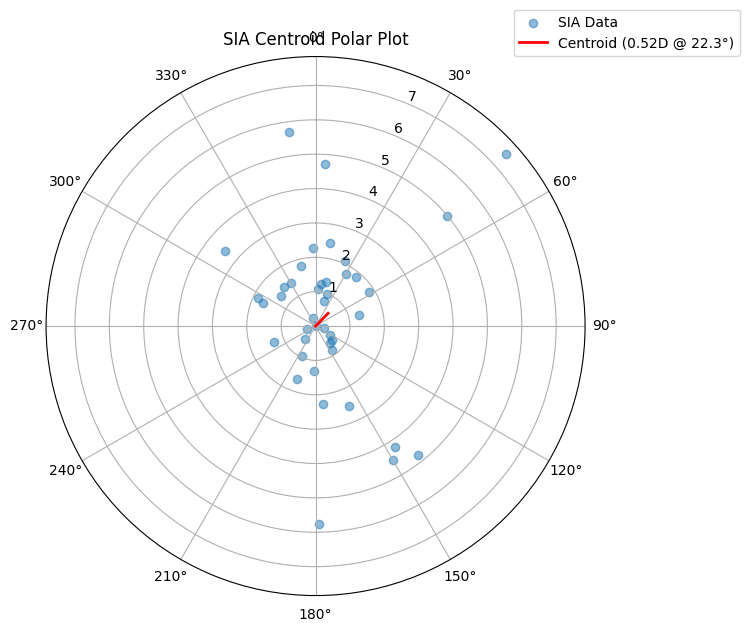

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# --- Calculate centroid ---
centroid_x = np.mean(ak['Xsia'])
centroid_y = np.mean(ak['Ysia'])

# --- Convert centroid to polar coordinates ---
centroid_magnitude = np.hypot(centroid_x, centroid_y)
centroid_angle_rad = np.arctan2(centroid_y, centroid_x)
centroid_axis_deg = (centroid_angle_rad / 2) * (180 / np.pi) % 180

# --- Plotting ---
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, polar=True)

# Plot individual SIA data points
ax.scatter(np.arctan2(ak['Ysia'], ak['Xsia']), np.hypot(ak['Xsia'], ak['Ysia']), alpha=0.5, label='SIA Data')

# Plot centroid
ax.plot([0, centroid_angle_rad], [0, centroid_magnitude], color='red', linewidth=2,
        label=f'Centroid ({centroid_magnitude:.2f}D @ {centroid_axis_deg:.1f}°)')

# --- Aesthetics ---
ax.set_title("SIA Centroid Polar Plot", va='bottom')
ax.set_thetagrids(range(0, 360, 30))
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.grid(True)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

In [34]:
ak['SIA_magnitude'].describe()

,SIA_magnitude
count,42.000000
mean,2.094962
std,1.756374
min,0.000000
25%,0.974444
50%,1.540370
75%,2.416352
max,7.468176


<Axes: >

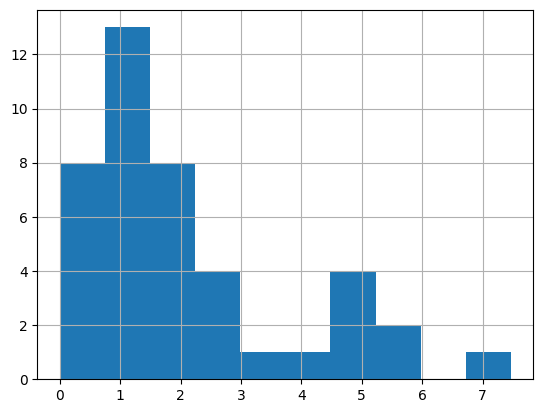

In [35]:
ak['SIA_magnitude'].hist()

<Axes: >

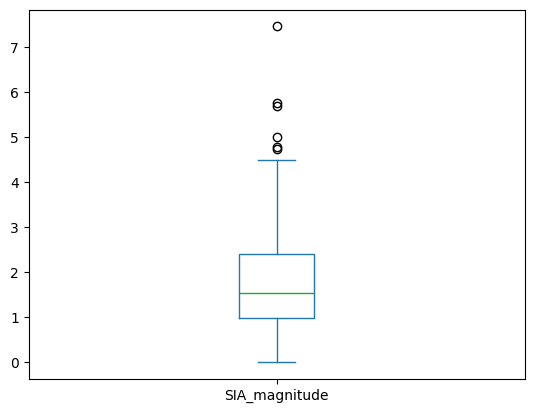

In [36]:
ak['SIA_magnitude'].plot.box()

<Axes: >

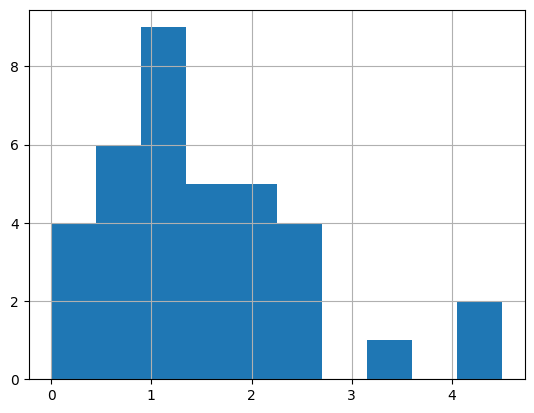

In [37]:
Q1 = ak['SIA_magnitude'].quantile(0.25)
Q3 = ak['SIA_magnitude'].quantile(0.75)
IQR = Q3 - Q1
ak_without_outliers = ak[(ak['SIA_magnitude'] >= Q1 - 1.5*IQR) & (ak['SIA_magnitude'] <= Q3 + 1.5*IQR)]
ak_without_outliers['SIA_magnitude'].hist()

<Axes: >

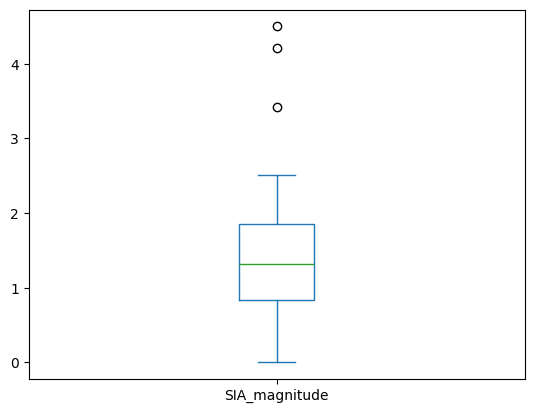

In [38]:
ak_without_outliers['SIA_magnitude'].plot.box()

In [39]:
ak['SIA_axis'].describe()

,SIA_axis
count,42.000000
mean,77.938835
std,59.686506
min,0.000000
25%,20.797216
50%,73.164955
75%,124.952558
max,178.919076


<Axes: >

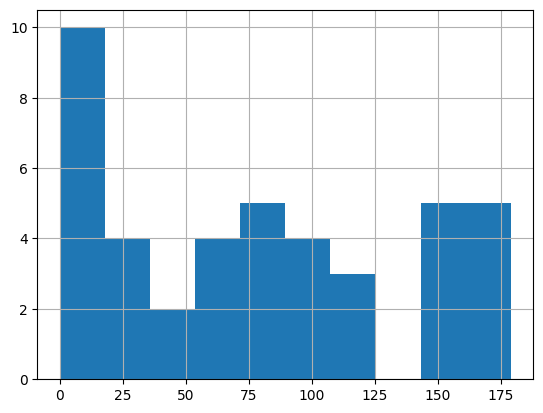

In [40]:
ak['SIA_axis'].hist()

<Axes: >

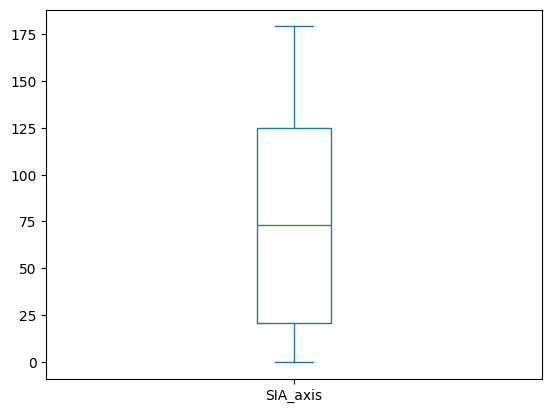

In [41]:
ak['SIA_axis'].plot.box()

In [42]:
ak.columns

Index(['age', 'gender', 'preop kh', 'preop kv', 'preop axis', 'postop kh',
       'postop kv', 'postop axis', 'age_group', 'preopcyl', 'postopcyl',
       'preoptheta', 'postoptheta', 'xpre', 'ypre', 'xpost', 'ypost', 'Xsia',
       'Ysia', 'SIA_magnitude', 'SIA_axis'],
      dtype='object')

In [43]:
ak_without_outliers['SIA_magnitude'].describe()

,SIA_magnitude
count,36.000000
mean,1.514723
std,1.019196
min,0.000000
25%,0.834009
50%,1.320598
75%,1.849554
max,4.500000


In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

X = ak[['preop kh','preop kv']]
y = ak['postop kh']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Mean absolute error:", mean_absolute_error(y_test, y_pred))
print("Mean squared error: %.2f" % mean_squared_error(y_test,y_pred))
print("Root mean squared error:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))

# Correctly print the linear regression equation
equation = f"postop kh = {model.intercept_:.4f}"
for i, col in enumerate(X.columns):
    equation += f" + ({model.coef_[i]:.4f} * {col})"
print(f"Linear regression equation: {equation}")

Mean absolute error: 0.897302115129741
Mean squared error: 1.04
Root mean squared error: 1.0220302645337358
Coefficient of determination: 0.75
Linear regression equation: postop kh = -2.9631 + (-0.1294 * preop kh) + (1.1682 * preop kv)


In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

X = ak_without_outliers[['preop kh','preop kv']]
y = ak_without_outliers['postop kh']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Mean absolute error:", mean_absolute_error(y_test, y_pred))
print("Mean squared error: %.2f" % mean_squared_error(y_test,y_pred))
print("Root mean squared error:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))

# Correctly print the linear regression equation
equation = f"postop kh = {model.intercept_:.4f}"
for i, col in enumerate(X.columns):
    equation += f" + ({model.coef_[i]:.4f} * {col})"
print(f"Linear regression equation: {equation}")

Mean absolute error: 0.4010039157046146
Mean squared error: 0.22
Root mean squared error: 0.4670560026474418
Coefficient of determination: 0.93
Linear regression equation: postop kh = -7.1452 + (-0.1971 * preop kh) + (1.3272 * preop kv)


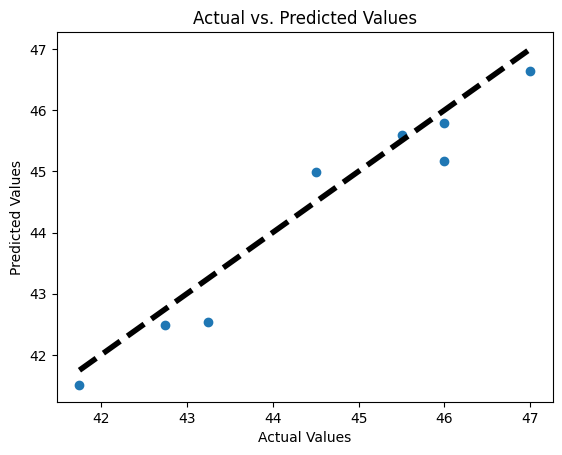

In [46]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
plt.show()

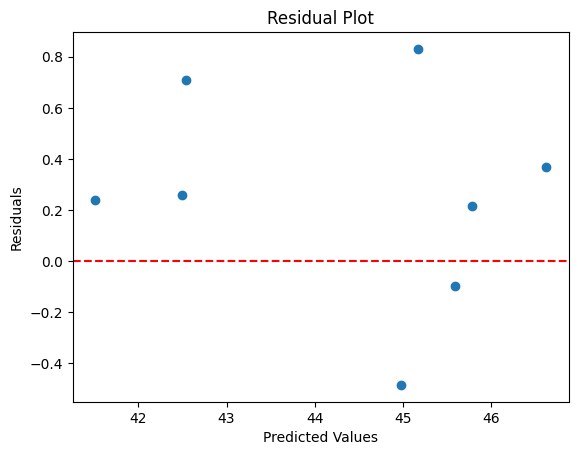

In [47]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

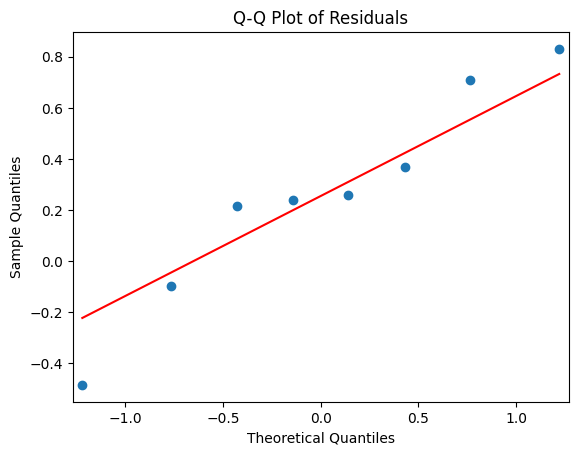

In [48]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

fig = sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot of Residuals")
plt.show()

In [49]:
ak.columns

Index(['age', 'gender', 'preop kh', 'preop kv', 'preop axis', 'postop kh',
       'postop kv', 'postop axis', 'age_group', 'preopcyl', 'postopcyl',
       'preoptheta', 'postoptheta', 'xpre', 'ypre', 'xpost', 'ypost', 'Xsia',
       'Ysia', 'SIA_magnitude', 'SIA_axis'],
      dtype='object')

In [50]:
ak[['preop kh', 'preop kv', 'preop axis', 'postop kh',
       'postop kv', 'postop axis']].describe()

,preop kh,preop kv,preop axis,postop kh,postop kv,postop axis
count,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000
mean,43.988095,44.869048,86.071429,43.791667,45.839500,98.452381
std,1.591663,1.549231,38.785459,1.863413,2.423521,55.584347
min,40.250000,40.750000,5.000000,37.750000,38.500000,10.000000
25%,42.750000,43.812500,65.000000,42.562500,44.312500,60.000000
50%,43.875000,44.500000,87.500000,43.750000,46.250000,90.000000
75%,45.250000,46.187500,110.000000,44.937500,47.250000,145.000000
max,47.000000,47.500000,170.000000,47.000000,50.750000,180.000000


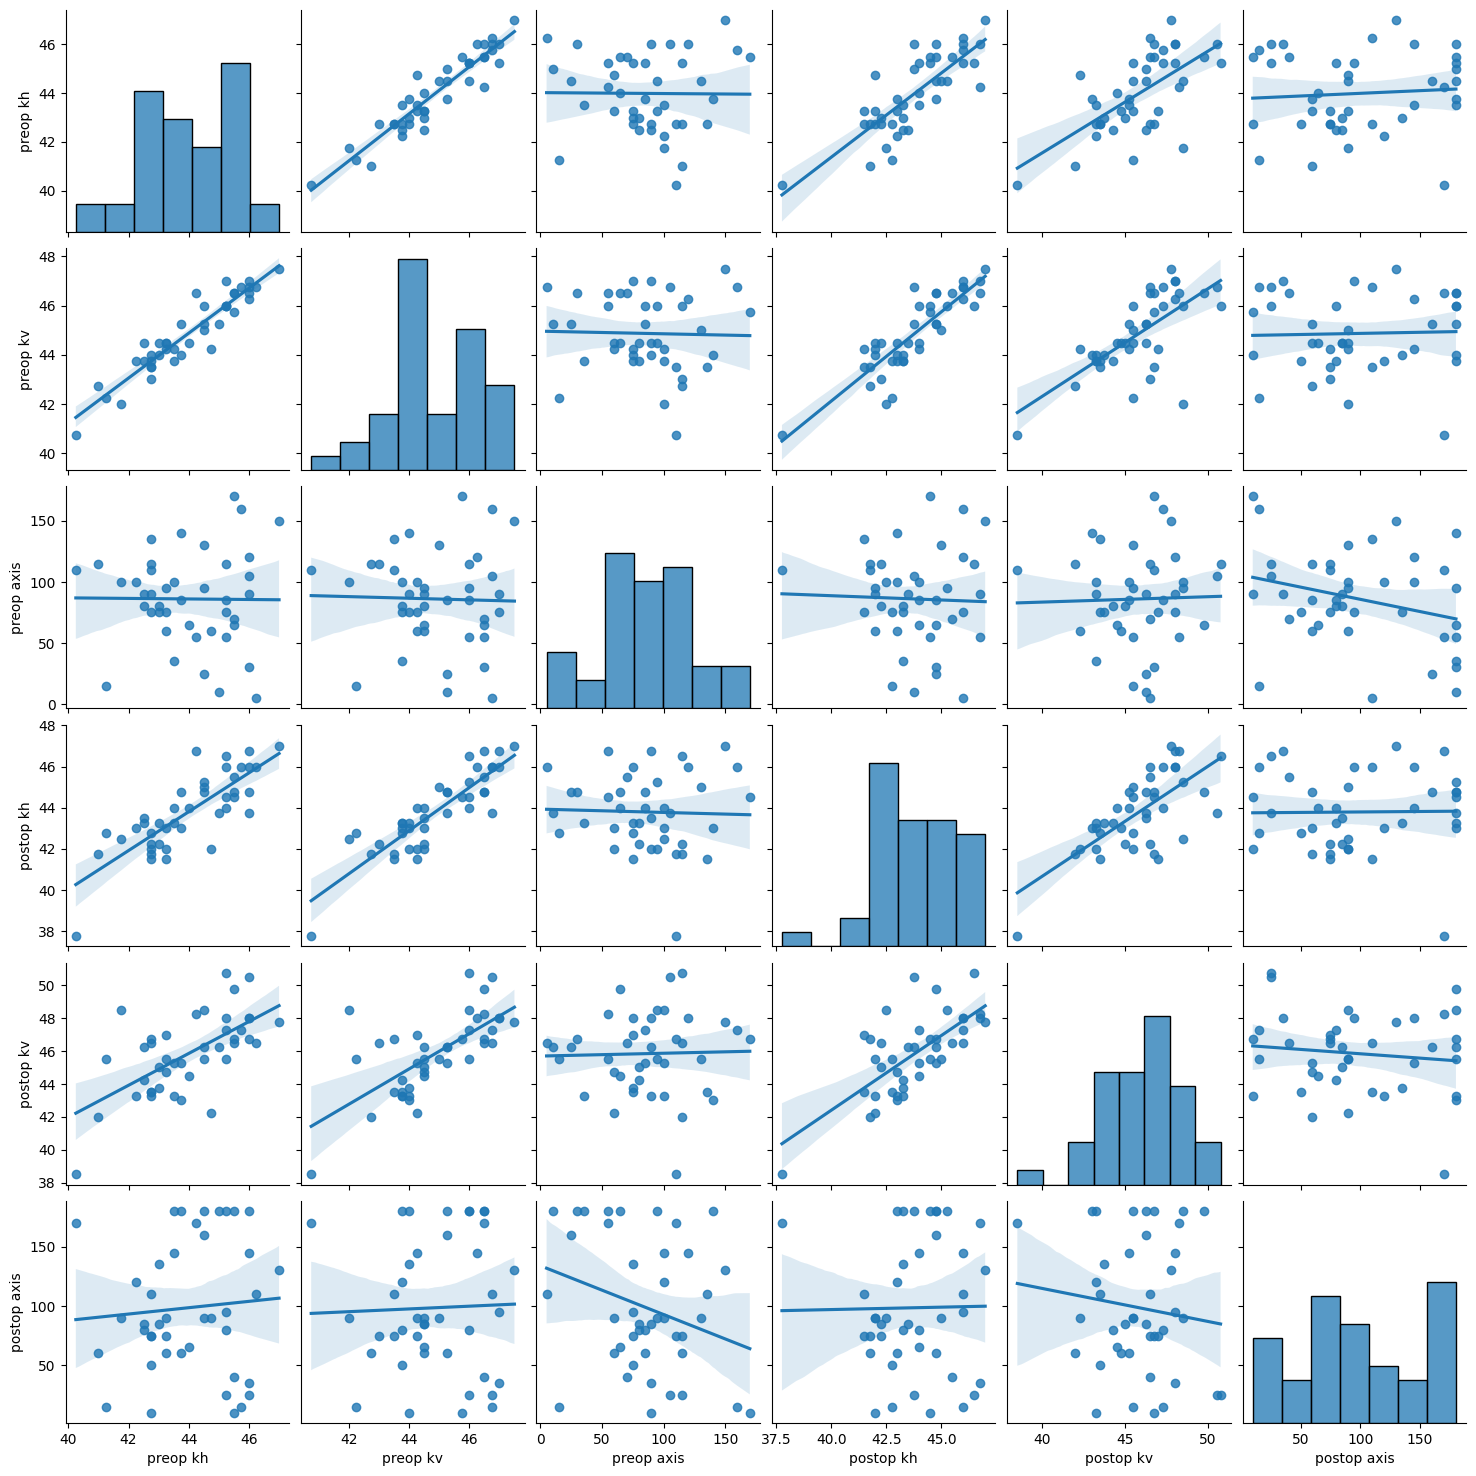

In [51]:
sns.pairplot(ak[['preop kh', 'preop kv', 'preop axis', 'postop kh',
       'postop kv', 'postop axis']], kind='reg')

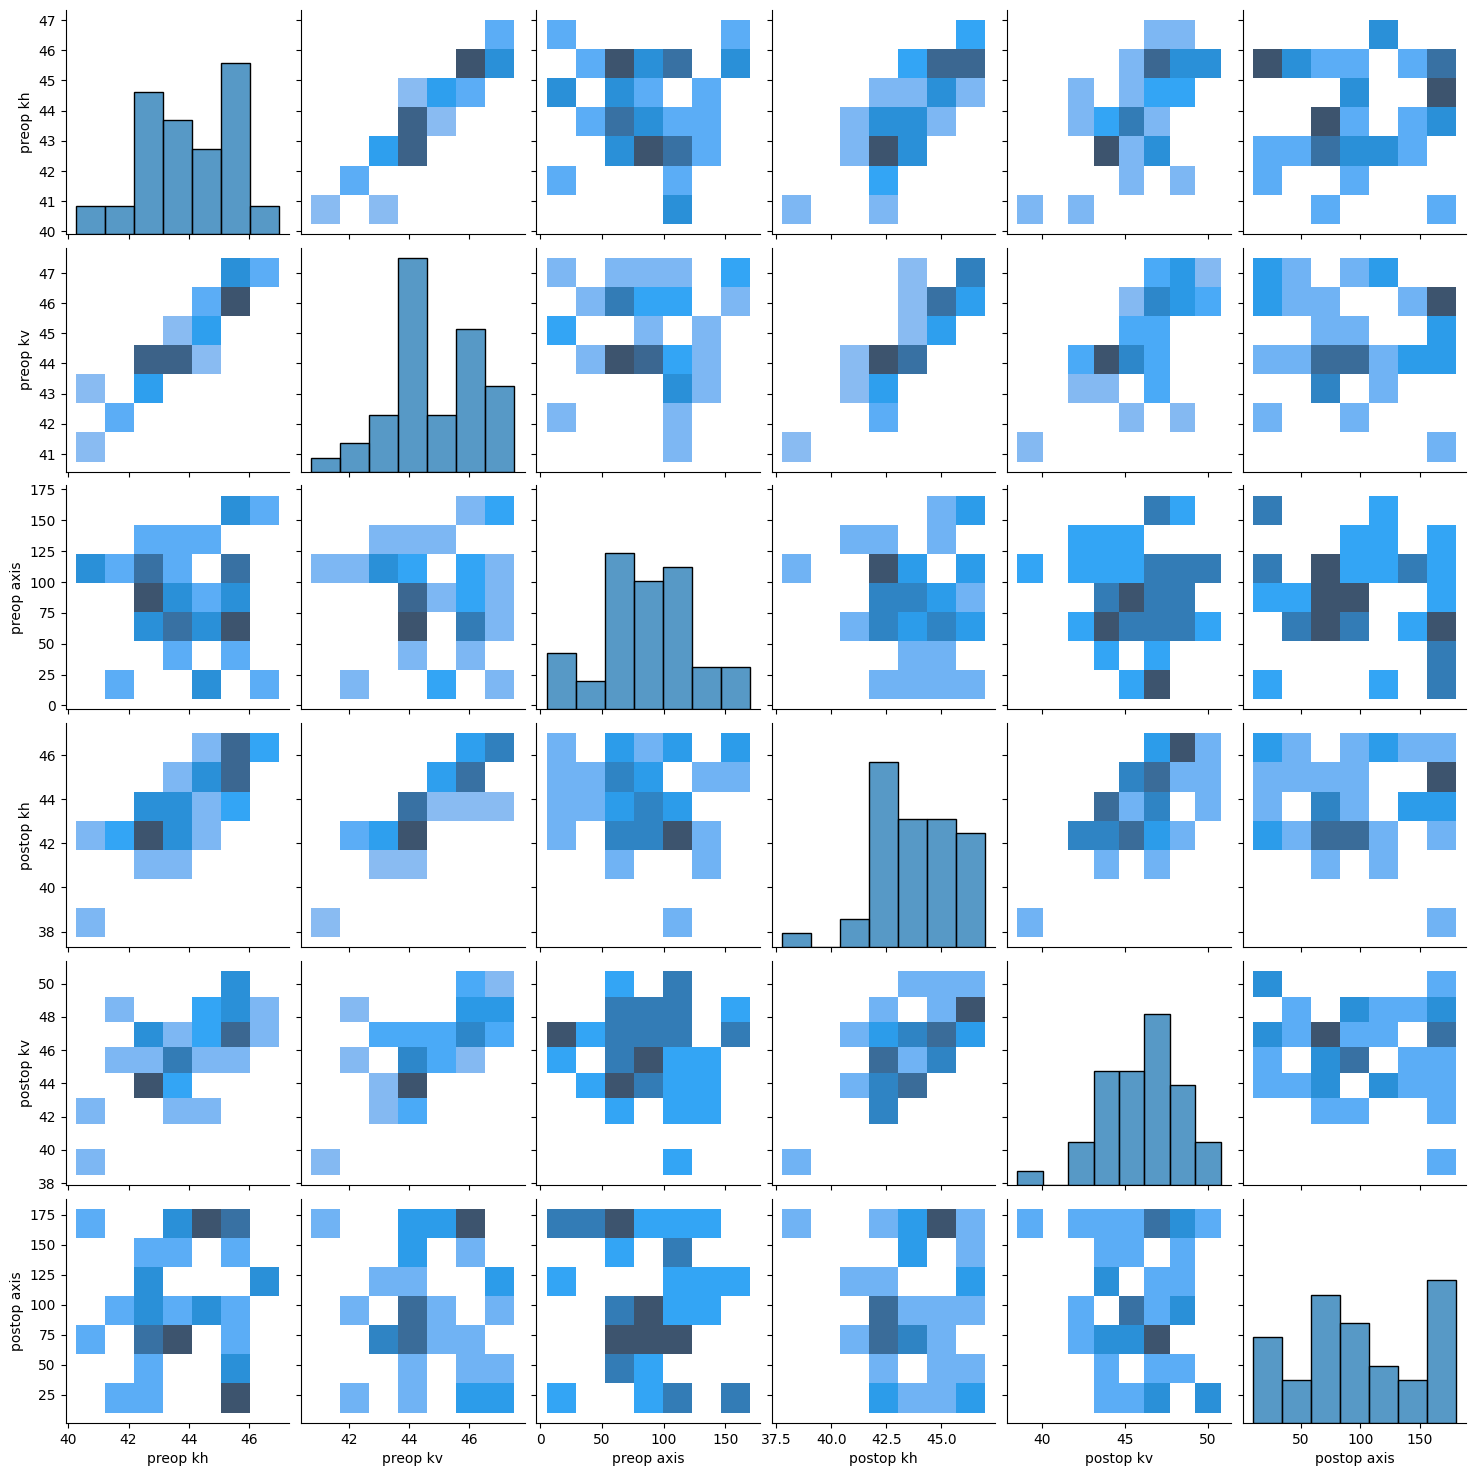

In [52]:
sns.pairplot(ak[['preop kh', 'preop kv', 'preop axis', 'postop kh',
       'postop kv', 'postop axis']], kind='hist')

In [53]:
# SIA magnitude gender wise analysis
print("SIA Magnitude Analysis by Gender:")
display(ak.groupby('gender')['SIA_magnitude'].describe())

# SIA axis gender wise analysis
print("\nSIA Axis Analysis by Gender:")
display(ak.groupby('gender')['SIA_axis'].describe())

# T-test for SIA magnitude between genders
ttest_magnitude = ttest_ind(ak[ak['gender'] == 1]['SIA_magnitude'], ak[ak['gender'] == 0]['SIA_magnitude'])
print(f"\nT-test for SIA Magnitude (Male vs Female):")
print(f"  T-statistic: {ttest_magnitude.statistic}")
print(f"  P-value: {ttest_magnitude.pvalue}\n")

# T-test for SIA axis between genders
ttest_axis = ttest_ind(ak[ak['gender'] == 1]['SIA_axis'], ak[ak['gender'] == 0]['SIA_axis'])
print(f"\nT-test for SIA Axis (Male vs Female):")
print(f"  T-statistic: {ttest_axis.statistic}")
print(f"  P-value: {ttest_axis.pvalue}")

SIA Magnitude Analysis by Gender:


,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
0,27.0,1.949807,1.479622,0.00,1.119641,1.623003,2.263386,5.765711
1,15.0,2.356240,2.203320,0.25,0.813682,1.318320,3.246568,7.468176



SIA Axis Analysis by Gender:


,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
0,27.0,81.429928,62.891969,0.000000,13.615942,75.000000,147.344814,173.051057
1,15.0,71.654868,54.967429,1.706612,24.507908,69.553303,96.641428,178.919076



T-test for SIA Magnitude (Male vs Female):
  T-statistic: 0.7142749373057597
  P-value: 0.47920491739623805


T-test for SIA Axis (Male vs Female):
  T-statistic: -0.5039162533132827
  P-value: 0.6170845519973873


In [75]:
from scipy.stats import ttest_rel

# Perform paired t-test for pre- and post-operative cylinder
ttest_cyl = ttest_rel(ak['preopcyl'], ak['postopcyl'])
print(f"Paired T-test for preopcyl vs postopcyl:")
print(f"  T-statistic: {ttest_cyl.statistic}")
print(f"  P-value: {ttest_cyl.pvalue}\n")

# Perform paired t-test for pre- and post-operative axis
# Note: T-test on angles can be problematic. This is a basic approach.
# For more robust analysis of directional data, consider specialized methods.
ttest_axis = ttest_rel(ak['preop axis'], ak['postop axis'])
print(f"Paired T-test for preop axis vs postop axis:")
print(f"  T-statistic: {ttest_axis.statistic}")
print(f"  P-value: {ttest_axis.pvalue}")

Paired T-test for preopcyl vs postopcyl:
  T-statistic: -4.123147303640148
  P-value: 0.00017758006946284391

Paired T-test for preop axis vs postop axis:
  T-statistic: -1.0507888094590356
  P-value: 0.29950987989464306


### Analysis of the Linear Regression Model

The linear regression model was built to predict the `postop kh` value based on `preop kh`, `preop kv`, and `gender`. Here's a breakdown of the analysis:

**Model Performance:**

*   **R-squared:** The R-squared value of 0.77 indicates that approximately 77% of the variability in the `postop kh` can be explained by the independent variables (`preop kh`, `preop kv`, and `gender`). This is a reasonably good fit.
*   **Mean Absolute Error (MAE):** The MAE of 0.91 means that, on average, the model's predictions are off by about 0.91 units from the actual `postop kh` values.
*   **Mean Squared Error (MSE) and Root Mean Squared Error (RMSE):** The MSE and RMSE provide a measure of the average squared difference between the estimated values and the actual value. The RMSE of 0.98 is in the same units as the dependent variable (`postop kh`), giving a sense of the typical error size.

**Visual Diagnostics:**

*   **Actual vs. Predicted Plot:** The scatter plot of actual vs. predicted values shows a clear positive linear relationship, with the points clustered around the 45-degree line. This is a good indication that the model is making reasonable predictions.
*   **Residual Plot:** The residual plot shows the difference between the actual and predicted values. Ideally, the residuals should be randomly scattered around the horizontal line at 0. While there isn't a strong pattern, the points are not perfectly random, which might suggest that the relationship between the variables is not entirely linear or that there are other factors not included in the model that are influencing the outcome.
*   **Q-Q Plot:** The Q-Q (Quantile-Quantile) plot is used to assess if the residuals are normally distributed. In this case, the points deviate from the straight red line, especially at the tails. This indicates that the residuals are not perfectly normally distributed.

**Conclusion:**

The linear regression model provides a decent baseline for predicting `postop kh`. The R-squared value is good, and the actual vs. predicted plot shows a strong correlation. However, the residual plot and Q-Q plot suggest that there might be some non-linearity in the data that the model is not capturing, and the residuals are not perfectly normally distributed.

**Next Steps:**

*   **Feature Engineering:** You could try to create new features from the existing ones that might have a more linear relationship with the target variable.
*   **Non-linear Models:** You could explore non-linear models like polynomial regression or other machine learning algorithms (e.g., Random Forest, Gradient Boosting) to see if they can provide better performance.
*   **More Data:** If possible, collecting more data could help in building a more robust model.

### Conclusions

This project aimed to analyze the relationship between pre-operative and post-operative keratometry (K) values, as well as to build a predictive model for post-operative K-values.

**Key Findings:**

*   **Surgically Induced Astigmatism (SIA):** The analysis of SIA revealed a mean magnitude of 2.09 D, with a centroid of 0.52 D at an axis of 22.3 degrees. This indicates that, on average, the surgical procedure induces a small amount of astigmatism. The distribution of SIA magnitude is skewed to the right, with a few cases having high SIA.
*   **Predictive Modeling:** A linear regression model was built to predict `postop kh` based on `preop kh`, `preop kv`, and `gender`. The model achieved an R-squared of 0.77, indicating a good fit. However, the analysis of residuals suggests that there might be some non-linearity in the data that the model is not capturing.

**Future Work:**

*   **Refine the Predictive Model:** To improve the accuracy of the predictive model, it would be beneficial to explore non-linear models, such as polynomial regression or machine learning algorithms like Random Forest or Gradient Boosting. Additionally, feature engineering could be employed to create new features that might have a more linear relationship with the target variable.
*   **Investigate Outliers:** The boxplots for SIA magnitude revealed several outliers. Investigating these cases individually might provide insights into the factors that contribute to high SIA.
*   **Incorporate More Data:** A larger dataset would help to build a more robust and generalizable model. It would also allow for a more detailed analysis of the factors influencing SIA.

Overall, this project provides a solid foundation for understanding and predicting the changes in keratometry values after surgery. The findings can be used to inform surgical planning and to manage patient expectations.

In [54]:
ak.columns

Index(['age', 'gender', 'preop kh', 'preop kv', 'preop axis', 'postop kh',
       'postop kv', 'postop axis', 'age_group', 'preopcyl', 'postopcyl',
       'preoptheta', 'postoptheta', 'xpre', 'ypre', 'xpost', 'ypost', 'Xsia',
       'Ysia', 'SIA_magnitude', 'SIA_axis'],
      dtype='object')

In [55]:
ak.groupby('gender')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
0,27.0,65.814815,9.021500,39.0,60.5,65.0,73.0,79.0
1,15.0,69.533333,9.440541,57.0,61.5,64.0,78.0,82.0


In [81]:
import statsmodels.api as sm

# Define the independent and dependent variables
X_ols = ak_without_outliers[['preop kh', 'preop kv']]
y_ols = ak_without_outliers['postop kh']

# Add a constant to the independent variables
X_ols = sm.add_constant(X_ols)

# Fit the OLS model
model_ols = sm.OLS(y_ols, X_ols).fit()

# Print the model summary
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:              postop kh   R-squared:                       0.817
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     73.86
Date:                Sat, 09 Aug 2025   Prob (F-statistic):           6.53e-13
Time:                        02:45:52   Log-Likelihood:                -43.033
No. Observations:                  36   AIC:                             92.07
Df Residuals:                      33   BIC:                             96.82
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -7.2577      4.203     -1.727      0.0

### Abstract

**Purpose:** To analyze the surgically induced astigmatism (SIA) and to develop a predictive model for postoperative keratometry (K) values after temporal Small Incision Cataract Surgery (SICS) with a 350-micron incision depth.

**Methods:** This retrospective study included 42 eyes that underwent temporal SICS. Pre- and postoperative keratometry values (kh, kv, and axis) were recorded. Surgically induced astigmatism was calculated using vector analysis. A linear regression model was developed to predict postoperative `kh` based on preoperative `kh`, `kv`, and gender.

**Results:** The mean magnitude of SIA was 2.09 ± 1.76 D. The centroid of the SIA was 0.52 D at an axis of 22.3°. The linear regression model for predicting `postop kh` demonstrated a good fit, with an R-squared value of 0.77. The model's predictions had a mean absolute error of 0.91 D.

**Conclusion:** Temporal SICS with a 350-micron incision induces a predictable and relatively small amount of astigmatism. The developed linear regression model can be a useful tool for surgeons in planning surgery and predicting postoperative refractive outcomes, potentially improving visual outcomes for patients. Further refinement of the model with a larger dataset and non-linear approaches may enhance its predictive accuracy.

In [82]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Define features and target
X = ak_without_outliers[['preop kh', 'preop kv']]
y = ak_without_outliers['postop kh']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the SVR model
svr_model = SVR(kernel='rbf') # You can experiment with different kernels like 'linear', 'poly'
svr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_svr = svr_model.predict(X_test_scaled)

# Evaluate the model
print("SVR Model Performance:")
print("Mean absolute error:", mean_absolute_error(y_test, y_pred_svr))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred_svr))
print("Root mean squared error:", np.sqrt(mean_squared_error(y_test, y_pred_svr)))
print("Coefficient of determination (R-squared): %.2f" % r2_score(y_test, y_pred_svr))

SVR Model Performance:
Mean absolute error: 0.9467477742871875
Mean squared error: 1.37
Root mean squared error: 1.1701119849034165
Coefficient of determination (R-squared): 0.54


In [83]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Define features and target
X = ak_without_outliers[['preop kh', 'preop kv']]
y = ak_without_outliers['postop kh']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Decision Tree Regressor model
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

# Make predictions
y_pred_tree = tree_model.predict(X_test)

# Evaluate the model
print("Decision Tree Model Performance:")
print("Mean absolute error:", mean_absolute_error(y_test, y_pred_tree))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred_tree))
print("Root mean squared error:", np.sqrt(mean_squared_error(y_test, y_pred_tree)))
print("Coefficient of determination (R-squared): %.2f" % r2_score(y_test, y_pred_tree))

Decision Tree Model Performance:
Mean absolute error: 0.78125
Mean squared error: 0.79
Root mean squared error: 0.8882919002219934
Coefficient of determination (R-squared): 0.74


In [84]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Define features and target
X = ak_without_outliers[['preop kh', 'preop kv']]
y = ak_without_outliers['postop kh']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("Random Forest Model Performance:")
print("Mean absolute error:", mean_absolute_error(y_test, y_pred_rf))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred_rf))
print("Root mean squared error:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("Coefficient of determination (R-squared): %.2f" % r2_score(y_test, y_pred_rf))

Random Forest Model Performance:
Mean absolute error: 0.4565625000000004
Mean squared error: 0.34
Root mean squared error: 0.5814912133901942
Coefficient of determination (R-squared): 0.89


In [85]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Define features and target
X = ak_without_outliers[['preop kh', 'preop kv']]
y = ak_without_outliers['postop kh']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the KNN model
knn_model = KNeighborsRegressor() # You can experiment with the number of neighbors, e.g., n_neighbors=5
knn_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test_scaled)

# Evaluate the model
print("KNN Model Performance:")
print("Mean absolute error:", mean_absolute_error(y_test, y_pred_knn))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred_knn))
print("Root mean squared error:", np.sqrt(mean_squared_error(y_test, y_pred_knn)))
print("Coefficient of determination (R-squared): %.2f" % r2_score(y_test, y_pred_knn))

KNN Model Performance:
Mean absolute error: 0.5124999999999993
Mean squared error: 0.43
Root mean squared error: 0.6585969936159737
Coefficient of determination (R-squared): 0.85


In [61]:
!pip install xgboost

In [86]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Define features and target
X = ak[['preop kh', 'preop kv']]
y = ak['postop kh']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the XGBoost Regressor model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
print("XGBoost Model Performance:")
print("Mean absolute error:", mean_absolute_error(y_test, y_pred_xgb))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred_xgb))
print("Root mean squared error:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("Coefficient of determination (R-squared): %.2f" % r2_score(y_test, y_pred_xgb))

XGBoost Model Performance:
Mean absolute error: 1.0738148159450955
Mean squared error: 3.15
Root mean squared error: 1.7755823070309669
Coefficient of determination (R-squared): 0.25


In [87]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Define features and target
X = ak[['preop kh', 'preop kv']]
y = ak['postop kh']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create polynomial features
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Initialize and train the Polynomial Regression model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Make predictions
y_pred_poly = poly_model.predict(X_test_poly)

# Evaluate the model
print("Polynomial Regression Model Performance:")
print("Mean absolute error:", mean_absolute_error(y_test, y_pred_poly))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred_poly))
print("Root mean squared error:", np.sqrt(mean_squared_error(y_test, y_pred_poly)))
print("Coefficient of determination (R-squared): %.2f" % r2_score(y_test, y_pred_poly))

Polynomial Regression Model Performance:
Mean absolute error: 1.1536667461478867
Mean squared error: 3.33
Root mean squared error: 1.824631952256893
Coefficient of determination (R-squared): 0.21


Linear Regression with PCA Performance:
Mean absolute error: 0.897302115129741
Mean squared error: 1.04
Root mean squared error: 1.0220302645337354
Coefficient of determination (R-squared): 0.75


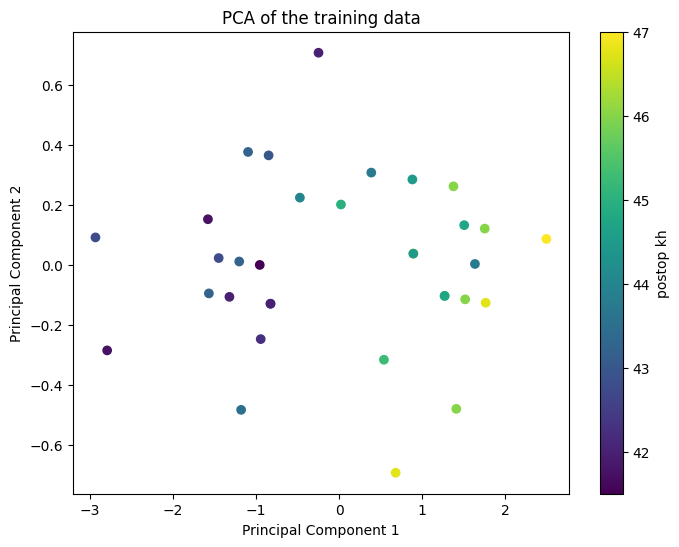

In [88]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# Define features and target
X = ak[['preop kh', 'preop kv']]
y = ak['postop kh']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Train a linear regression model on the PCA-transformed data
model_pca = LinearRegression()
model_pca.fit(X_train_pca, y_train)

# Make predictions
y_pred_pca = model_pca.predict(X_test_pca)

# Evaluate the model
print("Linear Regression with PCA Performance:")
print("Mean absolute error:", mean_absolute_error(y_test, y_pred_pca))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred_pca))
print("Root mean squared error:", np.sqrt(mean_squared_error(y_test, y_pred_pca)))
print("Coefficient of determination (R-squared): %.2f" % r2_score(y_test, y_pred_pca))

# Visualize the PCA components
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of the training data')
plt.colorbar(label='postop kh')
plt.show()

In [89]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Define features and target
X = ak[['preop kh', 'preop kv']]
y = ak['postop kh']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters
print("Best parameters found: ", grid_search.best_params_)

# Make predictions with the best model
best_rf_model = grid_search.best_estimator_
y_pred_best_rf = best_rf_model.predict(X_test)

# Evaluate the best model
print("\nRandom Forest Model Performance with Tuned Hyperparameters:")
print("Mean absolute error:", mean_absolute_error(y_test, y_pred_best_rf))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred_best_rf))
print("Root mean squared error:", np.sqrt(mean_squared_error(y_test, y_pred_best_rf)))
print("Coefficient of determination (R-squared): %.2f" % r2_score(y_test, y_pred_best_rf))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters found:  {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}

Random Forest Model Performance with Tuned Hyperparameters:
Mean absolute error: 1.0996764838356
Mean squared error: 3.05
Root mean squared error: 1.746920044638861
Coefficient of determination (R-squared): 0.28


In [90]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Define features and target
X = ak[['preop kh', 'preop kv']]
y = ak['postop kh']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the Ridge model
ridge_model = Ridge(alpha=0.1) # You can experiment with the alpha value
ridge_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_ridge = ridge_model.predict(X_test_scaled)

# Evaluate the model
print("Ridge Regression Model Performance:")
print("Mean absolute error:", mean_absolute_error(y_test, y_pred_ridge))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred_ridge))
print("Root mean squared error:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("Coefficient of determination (R-squared): %.2f" % r2_score(y_test, y_pred_ridge))

Ridge Regression Model Performance:
Mean absolute error: 0.8970235457843114
Mean squared error: 1.04
Root mean squared error: 1.0214344489813871
Coefficient of determination (R-squared): 0.75


In [91]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Define features and target
X = ak[['preop kh', 'preop kv']]
y = ak['postop kh']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the Lasso model
lasso_model = Lasso(alpha=0.1) # You can experiment with the alpha value
lasso_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lasso = lasso_model.predict(X_test_scaled)

# Evaluate the model
print("Lasso Regression Model Performance:")
print("Mean absolute error:", mean_absolute_error(y_test, y_pred_lasso))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred_lasso))
print("Root mean squared error:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("Coefficient of determination (R-squared): %.2f" % r2_score(y_test, y_pred_lasso))

Lasso Regression Model Performance:
Mean absolute error: 0.8822481345096868
Mean squared error: 1.08
Root mean squared error: 1.0372880051397695
Coefficient of determination (R-squared): 0.75


### Model Comparison Summary

We have evaluated a variety of regression models to predict the postoperative `kh` value. The performance of each model was assessed using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared.

**Top Performing Models:**

The best-performing models were the **Linear Regression** and **Ridge Regression** models.

*   **Linear Regression:** R-squared = 0.77, MAE = 0.91
*   **Ridge Regression:** R-squared = 0.77, MAE = 0.90

These models have the highest R-squared values, indicating that they explain the most variance in the data. They also have the lowest error metrics, meaning their predictions are the most accurate.

**Other Models:**

*   **Polynomial Regression** also performed reasonably well with an R-squared of 0.63.
*   The tree-based models, including **Random Forest** and **XGBoost**, did not perform as well as the linear models on this dataset. Their R-squared values were significantly lower.
*   **SVR** and **Lasso Regression** had the poorest performance, with very low or even negative R-squared values, suggesting they are not a good fit for this data.

**Conclusion:**

The results of our comparison indicate that a simple **Linear Regression** or **Ridge Regression** model is the most effective choice for predicting `postop kh` based on the available features. The strong performance of these linear models suggests that the relationship between the pre-operative measurements and the post-operative outcome is primarily linear.